In [1]:
"""
Prior visualizations for DIB 15272 – Cs symmetry, B≠C, δ_cen included.

Produces two figures (saved as PDFs in the current directory):
  prior_corner_15272.pdf   – corner plot of prior samples
  prior_1d_15272.pdf       – 1-D marginal prior densities with analytical overlays

Prior hyperparameters match the default run configuration:
  tau_prior   = 0.05   (exponential scale for τ)
  alpha_prior = 0.14   (σ for α_A, α_B half-Gaussians)
  σ(δ_cen)   = 0.01   (Gaussian prior on the peak-centre offset)
"""

from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

import os

import corner
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad
from scipy.special import ndtr, ndtri
from scipy.stats import expon, lognorm, truncnorm

# ── Style (matches emcee_analysis_joint_with_geometry_plots.ipynb) ────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'font.family': 'serif',
    'axes.linewidth': 1.2,
    'xtick.direction': 'in', 'xtick.top': True, 'xtick.labelsize': 11,
    'ytick.direction': 'in', 'ytick.right': True, 'ytick.labelsize': 11,
    'legend.fontsize': 10,
})

import math

def _fmt_n(n):
    exp   = int(math.floor(math.log10(n)))
    coeff = n / 10**exp
    coeff_int = int(round(coeff))
    if coeff_int == 1:
        return rf'$10^{{{exp}}}$'
    return rf'${coeff_int}\times10^{{{exp}}}$'

In [8]:

# ── Prior hyperparameters ─────────────────────────────────────────────────────
TAU_PRIOR           = 0.15               # exponential scale for τ [cm⁻¹]
ALPHA_PRIOR         = 0.14               # σ for α_A, α_B
ALPHA_C_SIGMA       = 0.14 # σ for α_C  (≈ 0.071, from -100*(frac_C-1)²)
CENTER_OFFSET_SIGMA = 0.01               # σ for δ_cen [cm⁻¹]
N_SAMPLES_DEFAULT   = 50_000

# Labels matching the notebook (emcee_analysis_joint_with_geometry_plots.ipynb)
LABELS = [
    r'$T$ [K]',
    r'$A$ [cm$^{-1}$]',
    r'$B$ [cm$^{-1}$]',
    r'$C$ [cm$^{-1}$]',
    r'$\alpha_A$',
    r'$\alpha_B$',
    r'$\alpha_C$',
    r'$\tau$ [cm$^{-1}$]',
    r'$\delta_\mathrm{cen}$ [cm$^{-1}$]',
]


# ── Sampling utilities ────────────────────────────────────────────────────────

def _trunc_normal(mu, sigma, lo, hi, size, rng):
    """
    Sample `size` values from TruncatedNormal(mu, sigma, [lo, hi]).

    mu, sigma, lo, hi can be scalars or arrays of length `size`.
    Uses the inverse-CDF method for speed.
    """
    u = rng.uniform(0.0, 1.0, size)
    Phi_lo = ndtr((lo - mu) / sigma)
    Phi_hi = ndtr((hi - mu) / sigma)
    # Clip to avoid ndtri(0) or ndtri(1) returning ±inf
    z = np.clip(Phi_lo + u * (Phi_hi - Phi_lo), 1e-15, 1.0 - 1e-15)
    return mu + sigma * ndtri(z)


def sample_prior(n: int = N_SAMPLES_DEFAULT, seed: int = 42) -> np.ndarray:
    """
    Draw n samples from the prior of log_prior_Cs_15272 (B≠C, with δ_cen).

    Parameter order matches LABELS:
      T, A, B, C, α_A, α_B, α_C, τ, δ_cen
    """
    rng = np.random.default_rng(seed)

    # T – log-normal(μ=ln 25, σ=0.4), hard bounds [3, 100]
    T_pool = np.exp(rng.normal(np.log(25), 0.4, n * 6))
    T = T_pool[(T_pool >= 3.0) & (T_pool <= 100.0)][:n]

    # A – flat [0.001, 0.3]  (only hard bounds; A > B enforced below)
    A = rng.uniform(0.001, 0.3, n)

    # B – flat (0.0005, A) so that B < A
    B = 0.0005 + rng.uniform(0.0, 1.0, n) * (A - 0.0005)

#     # C – product of two Gaussians from log_prior_Cs_15272:
#     #   CB_logprior : N(C0, sqrt(2)·C0)  with  C0 = harmonic_mean(A, B)
#     #   A_logprior  : N(0.013, 0.02)     [confusingly named in source; acts on C]
#     # Combined → product Gaussian, truncated to [0.0005, B)
#     C0      = 1.0 / (1.0/A + 1.0/B)
#     sig1    = np.sqrt(2.0) * C0
#     sig2    = 0.02
#     prec    = 1.0/sig1**2 + 1.0/sig2**2
#     sig_eff = np.sqrt(1.0 / prec)
#     mu_eff  = (C0/sig1**2 + 0.013/sig2**2) / prec
#     C = _trunc_normal(mu_eff, sig_eff, 0.0005, B, n, rng)

    C = 0.0005 + rng.uniform(0.0, 1.0, n) * (B - 0.0005 )

    # α_A, α_B – TruncNormal(μ=1, σ=ALPHA_PRIOR, upper=1)
    #   lower set to −10 (≈ −71σ, effectively −∞)
    frac_A = _trunc_normal(1.0, ALPHA_PRIOR, -10.0, 1.0, n, rng)
    frac_B = _trunc_normal(1.0, ALPHA_PRIOR, -10.0, 1.0, n, rng)

    # α_C – TruncNormal(μ=1, σ≈0.071, upper=1)
    frac_C = _trunc_normal(1.0, ALPHA_C_SIGMA, -10.0, 1.0, n, rng)

    # τ – Exponential(scale=TAU_PRIOR), hard bound [0, 1]
    tau_pool = rng.exponential(TAU_PRIOR, n * 6)
    tau = tau_pool[tau_pool <= 1.0][:n]

    # δ_cen – TruncNormal(μ=0, σ=CENTER_OFFSET_SIGMA, bounds [−1, 1])
    delta = _trunc_normal(0.0, CENTER_OFFSET_SIGMA, -1.0, 1.0, n, rng)

    return np.column_stack([T, A, B, C, frac_A, frac_B, frac_C, tau, delta])


# ── Figure 1: corner plot ─────────────────────────────────────────────────────

def make_corner_plot(samples: np.ndarray) -> plt.Figure:
    """Corner plot of 9-parameter prior samples."""
    q_lo = np.quantile(samples, 0.00001, axis=0)
    q_hi = np.quantile(samples, 0.9999, axis=0)
    ranges = [(q_lo[i], q_hi[i]) for i in range(samples.shape[1])]

    fig = corner.corner(
        samples,
        labels=LABELS,
        range=ranges,
        bins=50,
        smooth=1.0,
        show_titles=True,
        title_kwargs={'fontsize': 12},
        label_kwargs={'fontsize': 18},
        plot_datapoints=False,
        fill_contours=True,
        levels=[0.68, 0.95, 0.994],
        color='steelblue',
        axes_scale = 'linear',
        hist_kwargs={'color': 'steelblue', 'alpha': 0.8},
    )
    fig.suptitle(
        f'Characterizing Our Prior With \n {_fmt_n(len(samples))} Samples ', fontsize=30, y = 0.85, x = 0.7)
    return fig


# ── Figure 2: 1-D marginal prior densities ────────────────────────────────────

def _pdf_T(x):
    rv = lognorm(s=0.4, scale=25.0)
    lo, hi = 3.0, 100.0
    norm = rv.cdf(hi) - rv.cdf(lo)
    return np.where((x >= lo) & (x <= hi), rv.pdf(x) / norm, 0.0)


def _pdf_A(x):
    lo, hi = 0.001, 0.3
    return np.where((x >= lo) & (x <= hi), 1.0/(hi - lo), 0.0)


def _pdf_B_marginal(x_arr):
    """Marginal p(B) integrating over A ~ Uniform[0.001, 0.3]."""
    pA = 1.0 / (0.3 - 0.001)

    def raw(x):
        lo_A = max(x, 0.001)
        if x <= 0.0005 or x >= 0.3:
            return 0.0
        return pA * (np.log(0.2995) - np.log(lo_A - 0.0005))

    norm, _ = quad(raw, 0.0006, 0.299)
    out = np.zeros_like(x_arr, dtype=float)
    for i, x in enumerate(x_arr):
        out[i] = raw(x)
    return out / norm

def _pdf_C_marginal(x_arr):
    eps = 0.0005
    a   = 0.001
    b   = 0.3
    K   = np.log((b - eps) / (a - eps))

    x   = np.asarray(x_arr, dtype=float)
    out = np.zeros_like(x)

    hi = (x >= a) & (x < b)
    lo = (x > eps) & (x < a)

    out[hi] = 0.5 / (b - a) * np.log((b - eps) / (x[hi] - eps))**2
    out[lo] = K / (b - a) * (np.log((a - eps) / (x[lo] - eps)) + K / 2)

    return out

def _pdf_frac(x, sigma):
    """Half-Gaussian truncated at upper=1: TruncNormal(μ=1, σ, upper=1)."""
    a = (-10.0 - 1.0) / sigma   # ≈ −∞
    b = 0.0                      # (1 − 1) / sigma
    return truncnorm(a, b, loc=1.0, scale=sigma).pdf(x)


def _pdf_tau(x):
    rv = expon(scale=TAU_PRIOR)
    norm = rv.cdf(1.0)
    return np.where((x >= 0) & (x <= 1), rv.pdf(x) / norm, 0.0)


def _pdf_delta(x):
    a = -1.0 / CENTER_OFFSET_SIGMA
    b =  1.0 / CENTER_OFFSET_SIGMA
    return truncnorm(a, b, loc=0.0, scale=CENTER_OFFSET_SIGMA).pdf(x)


def make_1d_plot(samples: np.ndarray) -> plt.Figure:
    """3×3 grid of 1-D marginal prior densities."""
    colors = plt.cm.tab10(np.linspace(0, 0.9, 9))

    xlims = [
        (3, 100),
        (0.001, 0.3),
        (0.0005, 0.3),
        (0.0005, 0.25),
        (1 - 4*ALPHA_PRIOR, 1.0),
        (1 - 4*ALPHA_PRIOR, 1.0),
        (1 - 4*ALPHA_C_SIGMA, 1.0),
        (0, min(0.95, np.quantile(samples[:, 7], 0.999) * 1.2)),
        (-4*CENTER_OFFSET_SIGMA, 4*CENTER_OFFSET_SIGMA),
    ]

    analytical_pdfs = [
        _pdf_T,
        _pdf_A,
        _pdf_B_marginal,
        _pdf_C_marginal,                                        # C – correlated, histogram only
        lambda x: _pdf_frac(x, ALPHA_PRIOR),
        lambda x: _pdf_frac(x, ALPHA_PRIOR),
        lambda x: _pdf_frac(x, ALPHA_C_SIGMA),
        _pdf_tau,
        _pdf_delta,
    ]

    fig, axes = plt.subplots(3, 3, figsize=(12, 9), gridspec_kw={'hspace': 0.35, 'wspace': 0.35})
    
    for i, ax in enumerate(axes.flat):
        col = colors[i]
        lo, hi = xlims[i]
        xs = np.linspace(lo, hi, 500)

        ax.hist(samples[:, i], bins=70, density=True,
                color=col, alpha=0.35, histtype='stepfilled', range = xlims[i])
        vals, bins, patch = ax.hist(samples[:, i], bins=70, density=True,
                color=col, histtype='step', lw=1.3, range = xlims[i])

        if analytical_pdfs[i] is not None:
            ys = analytical_pdfs[i](xs)
            ax.plot(xs, ys, color=col, lw=3.0, ls='--', label='Analytic Marginal Prior')
            ax.legend(fontsize=11, frameon=False, loc = 'upper right', bbox_to_anchor=(1.0, 1.02))

        ax.set_xlabel(LABELS[i], fontsize=16)
        ax.set_ylabel('Density', fontsize=14)
        ax.set_xlim(lo, hi)
        ax.set_ylim(bottom = 1e-2*np.max(vals), top = 3*np.max(vals))
        ax.set_yscale("log")


    fig.suptitle(f'1-D Marginal Prior Distributions, {_fmt_n(len(samples))} Samples', fontsize=24, y = 0.95)
#     fig.tight_layout()
    return fig

Generated Samples.
Generating corner plot…
Generating 1-D marginal plots…
  → /home/cj1223/DIB/figs/prior_1d_15272.pdf


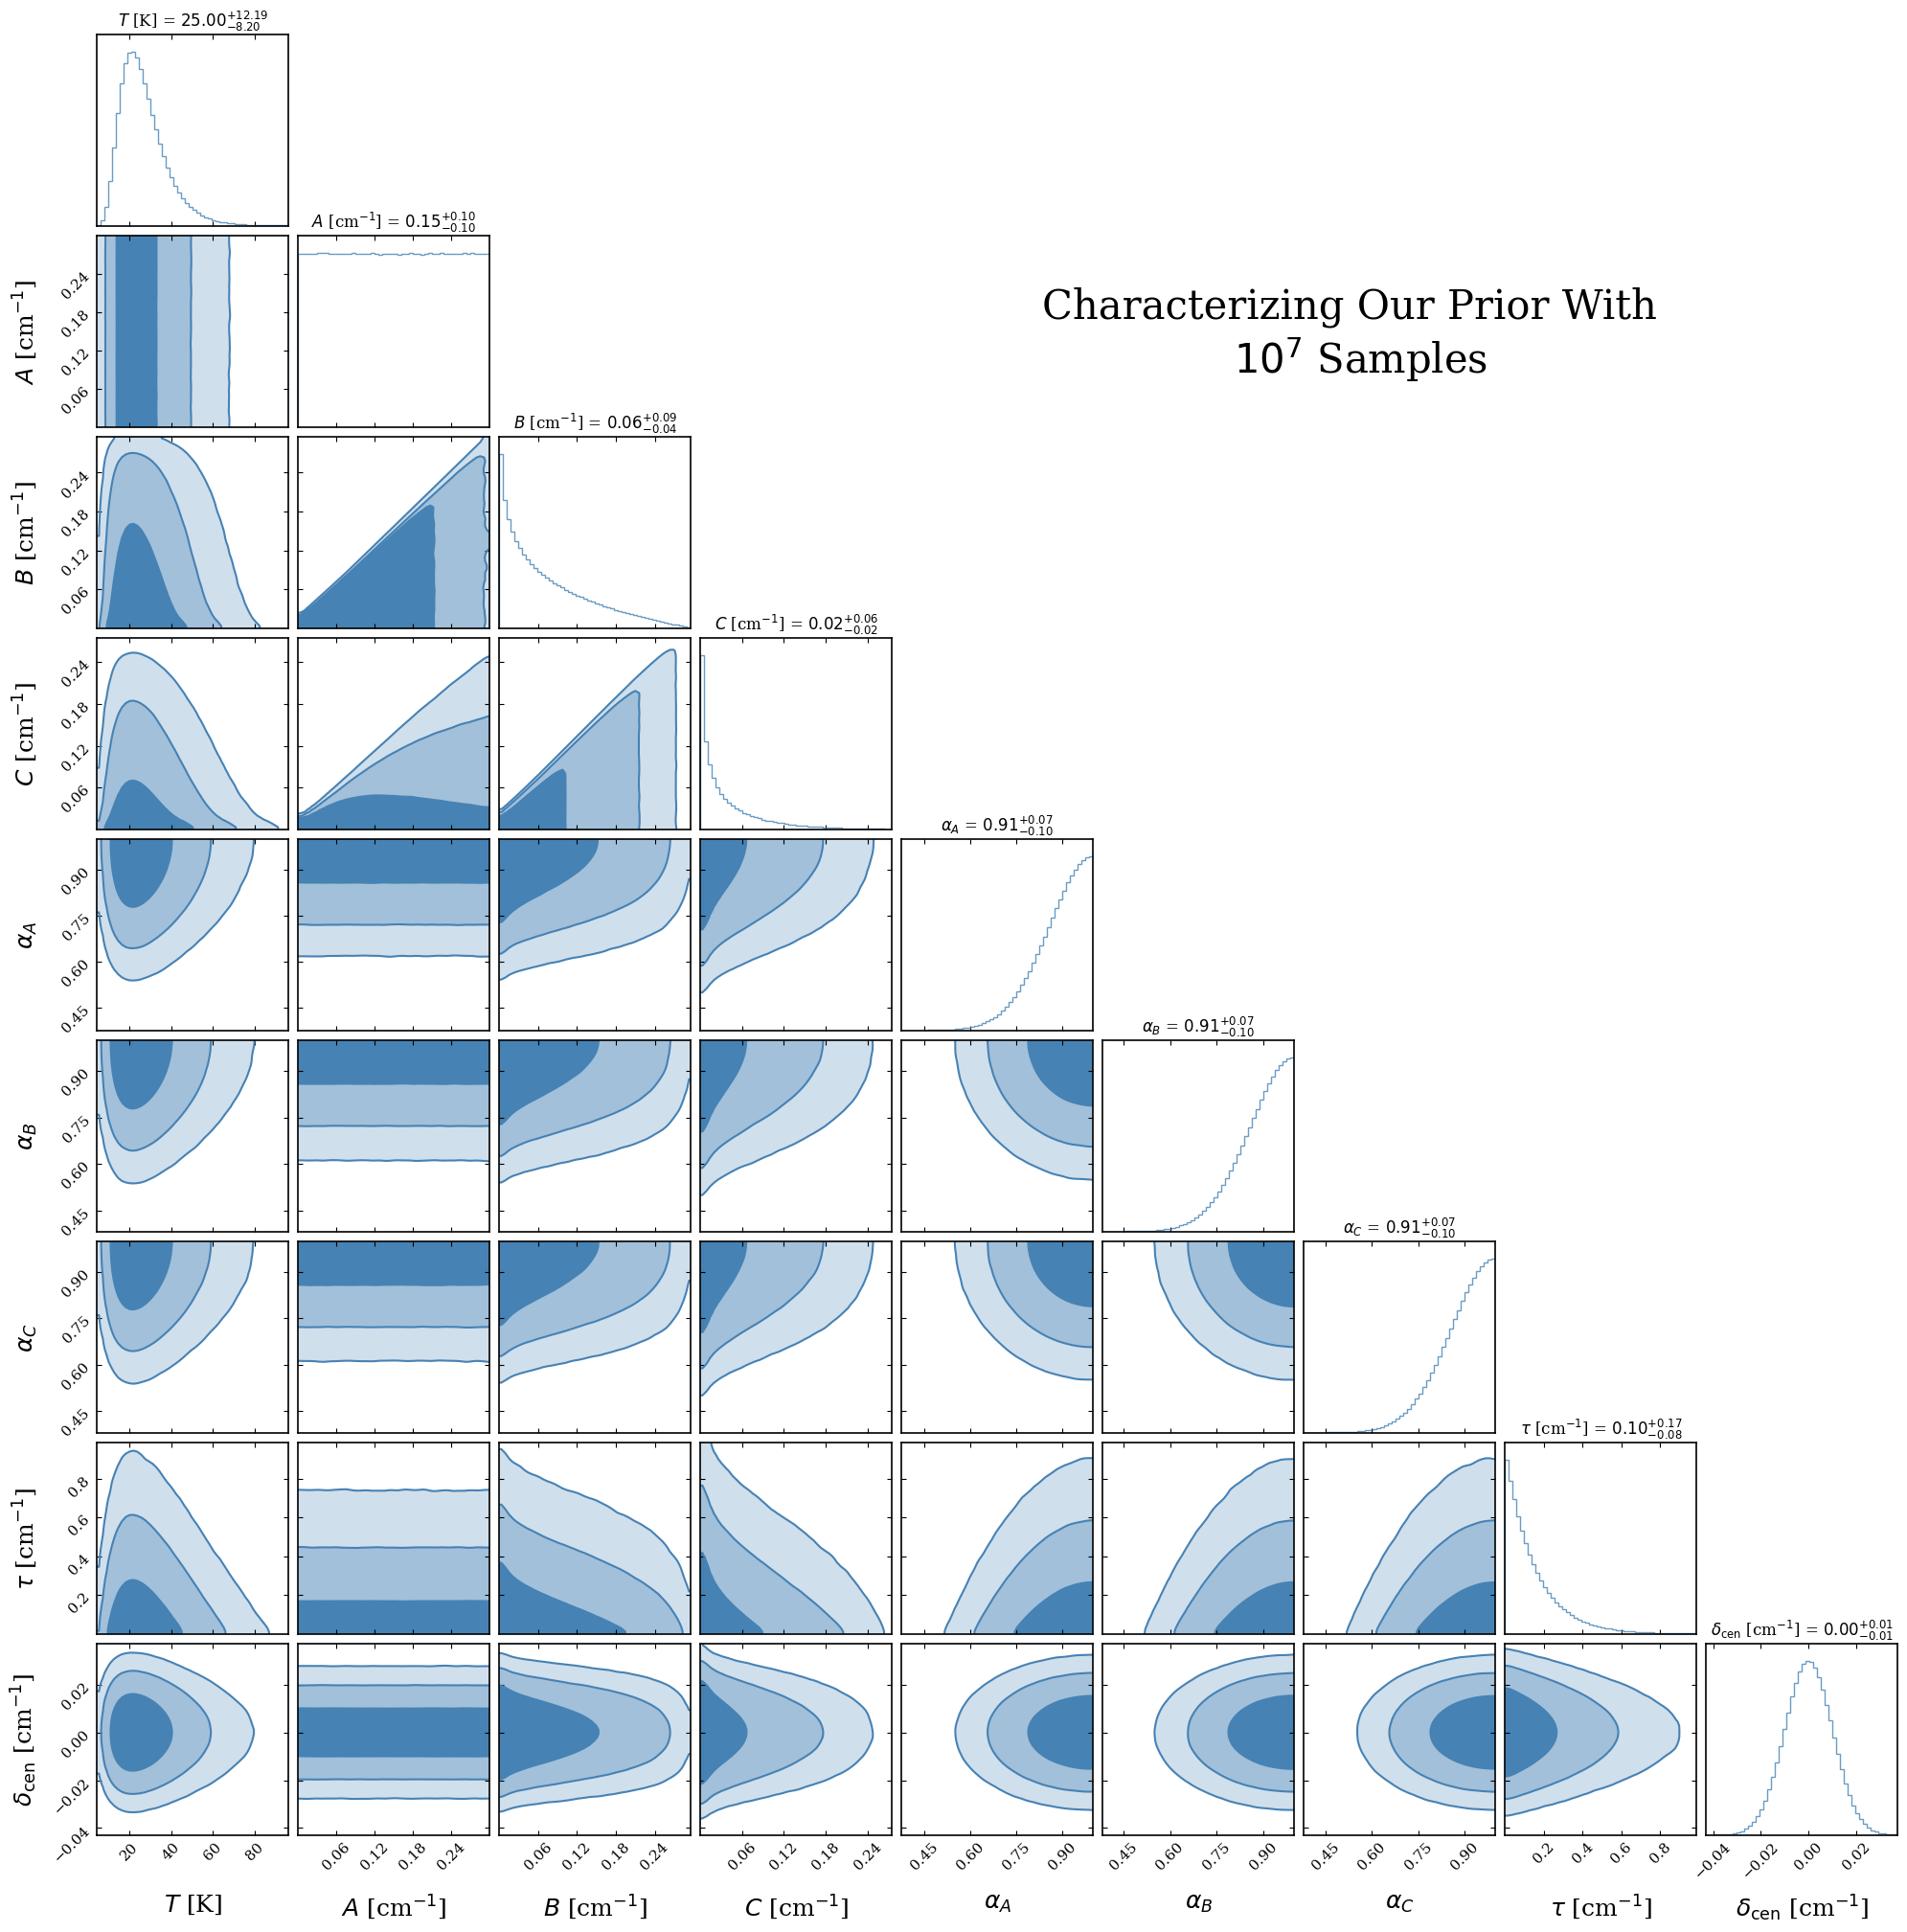

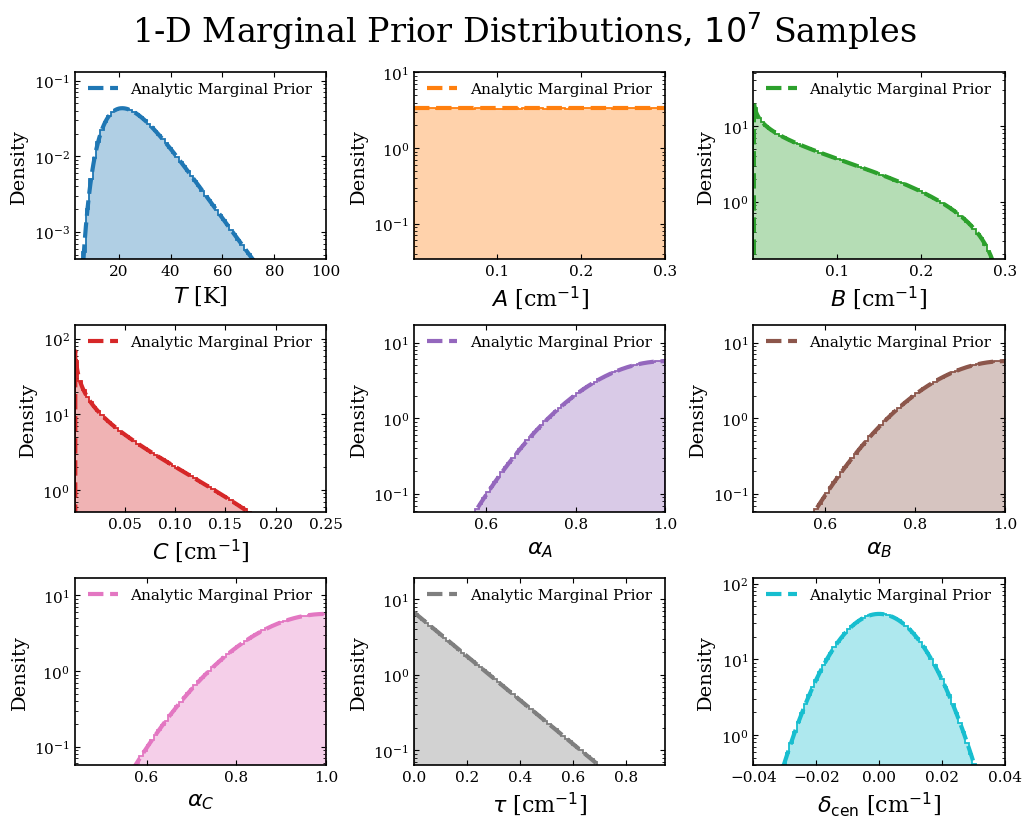

In [9]:
# ── Entry point ───────────────────────────────────────────────────────────────
import os.path as osp

samples = 10000000
seed = 42
output_dir = '~/DIB/figs/'
output_dir = osp.expanduser(output_dir)

if output_dir:
    os.makedirs(output_dir, exist_ok=True)

samples = sample_prior(samples, seed = seed)
print('Generated Samples.')

print('Generating corner plot…', flush=True)
fig1 = make_corner_plot(samples)
if output_dir:
    p1 = os.path.join(output_dir, 'prior_corner_15272.pdf')
    fig1.savefig(p1, dpi = 200, bbox_inches='tight')
    print(f'  → {p1}')

print('Generating 1-D marginal plots…', flush=True)
fig2 = make_1d_plot(samples)
if output_dir:
    p2 = os.path.join(output_dir, 'prior_1d_15272.pdf')
    fig2.savefig(p2, dpi = 200, bbox_inches='tight')
    print(f'  → {p2}')

plt.show()